# Stock Price Prediction Using Transformer Model
EE 559 - Machine Learning I

Name: Sungje Park


In [1]:
import pandas as pd
import jax
import jax.numpy as jnp
import optax
import numpy as np
from tqdm import tqdm
from functools import partial
import matplotlib.pyplot as plt
from models import TransformerModel

## Load dataset

In [2]:
train_data = pd.read_pickle('datasets/tall/train_data.pickle')
valid_data = pd.read_pickle('datasets/tall/valid_data.pickle')
test_data = pd.read_pickle('datasets/tall/test_data.pickle')

# train_mask = pd.read_pickle('datasets/tall/train_mask.pickle')
# valid_mask = pd.read_pickle('datasets/tall/valid_mask.pickle')
# test_mask = pd.read_pickle('datasets/tall/test_mask.pickle')

In [3]:
train_data.head()

,Open_ret_prev_close,High_ret_prev_close,Low_ret_prev_close,Close_ret_prev_close,rel_volume_yday,rel_adj_close,target_rel_adj_close
0,0.000000,0.009740,-0.009740,0.009740,-0.044109,0.009739,2.572377e-02
1,0.015000,0.035000,0.015000,0.020000,0.893365,0.020000,-9.803232e-03
2,0.000000,0.015328,-0.001226,0.015328,0.326862,0.015328,-6.409386e-09
3,0.000000,0.016778,0.000000,0.013423,-0.047573,0.013422,-2.778242e-07
4,-0.005017,-0.005017,-0.013378,-0.010033,-0.309835,-0.010039,-1.182966e-02


In [4]:
def seperate_x_y(df):
    x = jnp.asarray(df.drop(columns=['target_rel_adj_close']))
    y = jnp.asarray(df['target_rel_adj_close'])[...,jnp.newaxis]
    return x, y

train_data_x,train_data_y = seperate_x_y(train_data)
valid_data_x,valid_data_y = seperate_x_y(valid_data)
test_data_x,test_data_y = seperate_x_y(test_data)
print(f"Train data X shape: {train_data_x.shape}, Train data Y shape: {train_data_y.shape}")

Train data X shape: (3203872, 6), Train data Y shape: (3203872, 1)


## Basic NN Training

In [5]:
from models import BasicNetwork

num_layers = 5
d_hidden = 256
seed = 1234
lr = 1e-4
batch_size = 2056
num_epochs = 10000

nn = BasicNetwork(num_layers=num_layers,d_hidden=d_hidden)
params = nn.init(jax.random.PRNGKey(seed),train_data_x[:10])
num_params = sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Number of parameters in the model: {num_params}")

Number of parameters in the model: 265217


### Loss Def

In [6]:
def mse_loss(params,model,x,y):
    preds = model.apply(params,x)
    return jnp.mean((preds - y)**2)
# print(mse_loss(params,nn,train_data_x,train_data_y))

In [7]:
def subsample_data(key,x,y,batch_size):
    ind = jax.random.choice(key, x.shape[0], (batch_size,), replace=False)
    return x[ind], y[ind]

In [8]:
optimizer = optax.adam(learning_rate=lr)
opt_state = optimizer.init(params)

In [9]:
@partial(jax.jit, static_argnums=0)
def step(model,params,opt_state,x,y,rng_key):
    rng_key, subkey = jax.random.split(rng_key)
    x,y = subsample_data(subkey,x,y,batch_size)
    loss, grads = jax.value_and_grad(mse_loss,argnums=0)(params,model,x,y)
    updates, opt_state = optimizer.update(grads,opt_state)
    params = optax.apply_updates(params,updates)
    return params,opt_state,loss,rng_key

@partial(jax.jit, static_argnums=0)
def evaluate(model,params,key,x,y):
    x,y = subsample_data(key,x,y,batch_size)
    return mse_loss(params,model,x,y)

### Training

In [10]:
rng_key = jax.random.PRNGKey(seed)
loss_track = []
v_loss_track = []
for _ in tqdm(range(num_epochs)):
    params,opt_state,loss,rng_key = step(nn,params,opt_state,train_data_x,train_data_y,rng_key)
    v_loss = evaluate(nn,params,rng_key,valid_data_x,valid_data_y)
    loss_track.append(loss)
    v_loss_track.append(v_loss)

100%|██████████| 10000/10000 [00:13<00:00, 726.76it/s]


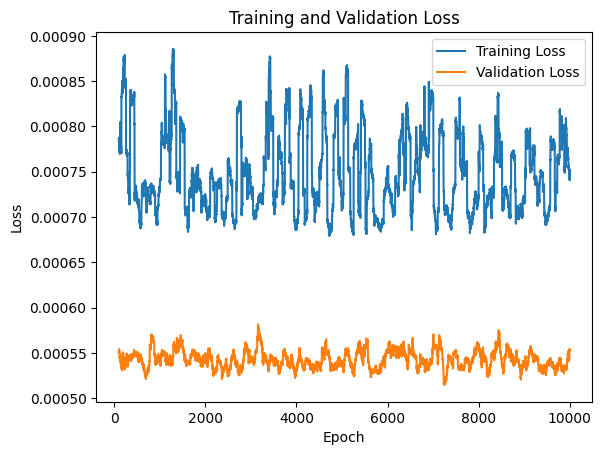

In [12]:
rolling_loss = pd.Series(loss_track).rolling(window=100).mean()
rolling_v_loss = pd.Series(v_loss_track).rolling(window=100).mean()

plt.plot(rolling_loss)
plt.plot(rolling_v_loss)
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.savefig('figures/nn_training_loss.png')
plt.show()

In [13]:
@jax.jit
def evaluate(x,y):
    pred = nn.apply(params,x)
    mse = jnp.mean((pred - y)**2)
    sign_pred = jnp.sign(pred.flatten())
    sign_true = jnp.sign(y.flatten())
    accuracy = jnp.mean(sign_pred == sign_true, where=mask.flatten())
    return mse, accuracy
    
@jax.jit
def raw_eval(x,y):
    pred = nn.apply(params,x)
    mse = (pred - y)**2
    sign_pred = jnp.sign(pred.flatten())
    sign_true = jnp.sign(y.flatten())
    accuracy = sign_pred == sign_true
    positive_pred = sign_pred > 0
    positive_true = sign_true > 0
    return mse, accuracy, positive_pred, positive_true

def batch_evaluate(x,y,batch_size):
    num_samples = x.shape[0]
    mse = []
    accuracy = []
    positive_pred = []
    positive_true = []
    for i in range(0, num_samples, batch_size):
        batch_x = x[i:i+batch_size]
        batch_y = y[i:i+batch_size]
        batch_mse, batch_acc, batch_pos_pred, batch_pos_true = raw_eval(batch_x, batch_y)
        mse.append(batch_mse)
        accuracy.append(batch_acc)
        positive_pred.append(batch_pos_pred)
        positive_true.append(batch_pos_true)
    mse = jnp.mean(jnp.concatenate(mse))
    accuracy = jnp.mean(jnp.concatenate(accuracy))
    pred_pos = jnp.concatenate(positive_pred)
    true_pos = jnp.concatenate(positive_true)
    tp = jnp.sum(pred_pos & true_pos)
    fp = jnp.sum(pred_pos & ~true_pos)
    fn = jnp.sum((~pred_pos) & true_pos)
    eps = 1e-12
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    return mse, accuracy, precision, recall, f1
        
def print_eval_metrics(mse, acc, precision, recall, f1, dataset_name):
    print(f"{dataset_name} MSE: {mse:.6f}, Sign Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

In [14]:
eval_batch = 1024

train_mse, train_acc, train_precision, train_recall, train_f1 = batch_evaluate(train_data_x, train_data_y,eval_batch)
print_eval_metrics(train_mse, train_acc, train_precision, train_recall, train_f1, "Train")
valid_mse, valid_acc, valid_precision, valid_recall, valid_f1 = batch_evaluate(valid_data_x, valid_data_y,eval_batch)
print_eval_metrics(valid_mse, valid_acc, valid_precision, valid_recall, valid_f1, "Validation")
test_mse, test_acc, test_precision, test_recall, test_f1 = batch_evaluate(test_data_x, test_data_y,eval_batch)
print_eval_metrics(test_mse, test_acc, test_precision, test_recall, test_f1, "Test")

Train MSE: 0.000751, Sign Accuracy: 0.4849, Precision: 0.4329, Recall: 0.6736, F1: 0.5270
Validation MSE: 0.000541, Sign Accuracy: 0.5149, Precision: 0.5133, Recall: 0.6702, F1: 0.5814
Test MSE: 0.000876, Sign Accuracy: 0.5082, Precision: 0.5078, Recall: 0.6832, F1: 0.5826
